In [1]:
# Task 2: Variational Autoencoder (VAE)
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
import sys
import matplotlib.pyplot as plt
sys.path.append('../src')
from preprocessing.piano_roll import piano_roll_to_midi
from models.vae import MusicVAE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


In [2]:
# Load Datasets
train_data = np.load('../data/train_test_split/train.npy')
val_data = np.load('../data/train_test_split/val.npy')

# Reshape to (batch, seq_len, pitch)
train_tensor = torch.tensor(train_data, dtype=torch.float32).permute(0, 2, 1)
val_tensor = torch.tensor(val_data, dtype=torch.float32).permute(0, 2, 1)

print('Train tensor shape:', train_tensor.shape)
print('Val tensor shape:', val_tensor.shape)

train_dataset = TensorDataset(train_tensor)
val_dataset = TensorDataset(val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


Train tensor shape: torch.Size([25108, 128, 88])
Val tensor shape: torch.Size([4570, 128, 88])


In [3]:
# Initialize Model
model = MusicVAE(input_size=88, hidden_size=256, latent_size=128, enc_num_layers=2, dec_num_layers=1).to(device)

# Weighted BCE Loss to handle 94% sparsity (pos_weight in range 10-30 per guideline)
pos_weight = torch.tensor([20.0]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Adam with lr=1e-3 as recommended by guideline Section D
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# KL Divergence Loss
def kl_divergence(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

# KL Annealing: warmup over 20 epochs, beta_max=0.05 to allow the latent space to be used
# (Setting beta too high causes the decoder to ignore z. A low beta fixes posterior collapse).
def get_kl_weight(epoch, warmup_epochs=20, beta_max=0.05):
    return min(beta_max, beta_max * epoch / warmup_epochs)


In [4]:
# Training Loop - 50 epochs with KL annealing over 40 epochs
num_epochs = 50
train_losses = []
val_losses = []
train_recon_losses = []
train_kl_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    epoch_recon = 0
    epoch_kl = 0
    kl_weight = get_kl_weight(epoch, 20)
    
    for batch in train_loader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        
        reconstructed, mu, logvar = model(x)
        
        recon_loss = criterion(reconstructed, x)
        kl_loss = kl_divergence(mu, logvar) / (x.size(0) * x.size(1) * x.size(2)) # Normalize
        
        loss = recon_loss + kl_weight * kl_loss
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()
        
    avg_train_loss = epoch_loss / len(train_loader)
    avg_train_recon = epoch_recon / len(train_loader)
    avg_train_kl = epoch_kl / len(train_loader)
    train_losses.append(avg_train_loss)
    train_recon_losses.append(avg_train_recon)
    train_kl_losses.append(avg_train_kl)
    
    # Validation step
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            x = batch[0].to(device)
            reconstructed, mu, logvar = model(x)
            
            recon_loss = criterion(reconstructed, x)
            kl_loss = kl_divergence(mu, logvar) / (x.size(0) * x.size(1) * x.size(2))
            
            loss = recon_loss + kl_weight * kl_loss
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | KL W: {kl_weight:.2f} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | Recon: {avg_train_recon:.6f} | KL: {avg_train_kl:.6f}")


Epoch [1/50] | KL W: 0.00 | Train Loss: 1.361081 | Val Loss: 1.302198 | Recon: 1.361081 | KL: 0.051291


Epoch [2/50] | KL W: 0.00 | Train Loss: 1.357552 | Val Loss: 1.305643 | Recon: 1.357471 | KL: 0.032544


Epoch [3/50] | KL W: 0.01 | Train Loss: 1.357352 | Val Loss: 1.304957 | Recon: 1.357265 | KL: 0.017545


Epoch [4/50] | KL W: 0.01 | Train Loss: 1.357225 | Val Loss: 1.314998 | Recon: 1.357151 | KL: 0.009848


Epoch [5/50] | KL W: 0.01 | Train Loss: 1.356977 | Val Loss: 1.297316 | Recon: 1.356857 | KL: 0.011968


...

Epoch [46/50] | KL W: 0.05 | Train Loss: 1.355929 | Val Loss: 1.303648 | Recon: 1.355638 | KL: 0.005824


Epoch [47/50] | KL W: 0.05 | Train Loss: 1.363608 | Val Loss: 1.311681 | Recon: 1.359935 | KL: 0.073460


Epoch [48/50] | KL W: 0.05 | Train Loss: 1.360265 | Val Loss: 1.298609 | Recon: 1.357566 | KL: 0.053981


Epoch [49/50] | KL W: 0.05 | Train Loss: 1.363307 | Val Loss: 1.299109 | Recon: 1.359057 | KL: 0.084998


Epoch [50/50] | KL W: 0.05 | Train Loss: 1.356715 | Val Loss: 1.301062 | Recon: 1.355299 | KL: 0.028314


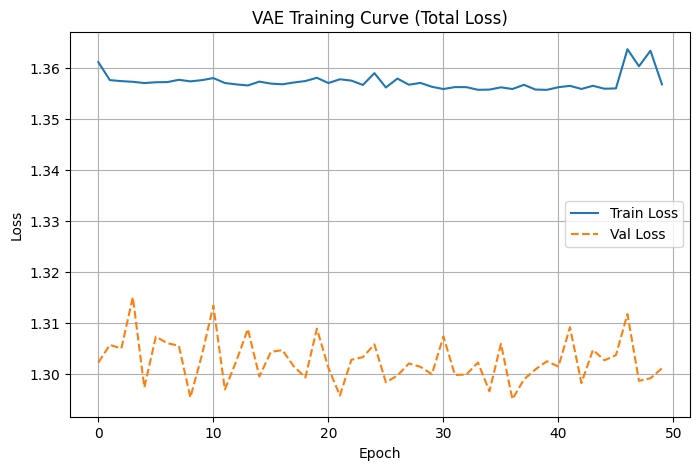

In [5]:
# Plot 1: Total Training and Validation Loss (guideline Step 11)
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', linestyle='-')
plt.plot(val_losses, label='Val Loss', linestyle='--')
plt.legend()
plt.title('VAE Training Curve (Total Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


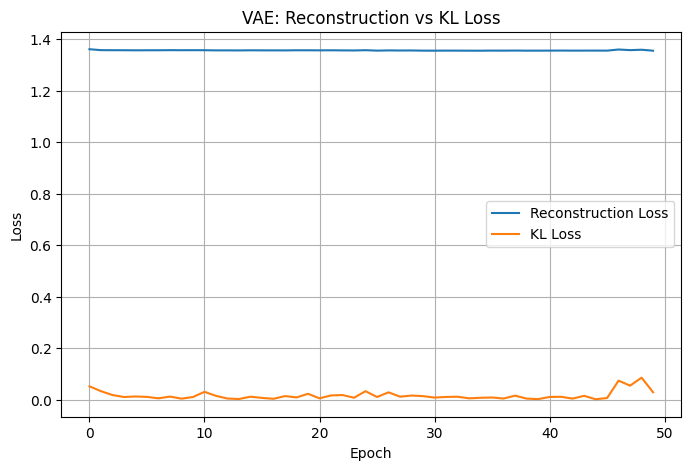

In [6]:
# Plot 2: Separate KL and Reconstruction Loss (required by guideline Step 11)
plt.figure(figsize=(8, 5))
plt.plot(train_recon_losses, label='Reconstruction Loss', linestyle='-')
plt.plot(train_kl_losses, label='KL Loss', linestyle='-')
plt.legend()
plt.title('VAE: Reconstruction vs KL Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


In [7]:
# Save Model
output_dir = Path("../outputs/generated_midis/task2_vae")
output_dir.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), "../outputs/checkpoints/vae.pth")
print("Model saved.")


Model saved.


In [8]:
# Latent Space Interpolation (required by guideline: 8 intermediate outputs)
model.eval()
with torch.no_grad():
    x1 = val_tensor[0:1].to(device)
    x2 = val_tensor[50:51].to(device)
    
    mu1, _ = model.encode(x1)
    mu2, _ = model.encode(x2)
    
    steps = 8
    alphas = np.linspace(0, 1, steps)
    
    for i, alpha in enumerate(alphas):
        z_interp = mu1 * (1 - alpha) + mu2 * alpha
        
        reconstructed = model.decode(z_interp, seq_len=128)
        reconstructed_probs = torch.sigmoid(reconstructed)
        
        # Binarize with lowered threshold (below 0.5 per guideline)
        reconstructed_roll = (reconstructed_probs.squeeze(0).cpu().numpy().T > 0.3).astype(float)
        
        output_path = output_dir / f"vae_interp_step_{i+1}.mid"
        piano_roll_to_midi(reconstructed_roll, output_path, fs=16)
        print("Saved interpolation step:", output_path)


Saved interpolation step:

 ..\outputs\generated_midis\task2_vae\vae_interp_step_1.mid
Saved interpolation step: ..\outputs\generated_midis\task2_vae\vae_interp_step_2.mid
Saved interpolation step: ..\outputs\generated_midis\task2_vae\vae_interp_step_3.mid
Saved interpolation step: ..\outputs\generated_midis\task2_vae\vae_interp_step_4.mid
Saved interpolation step: ..\outputs\generated_midis\task2_vae\vae_interp_step_5.mid
Saved interpolation step: ..\outputs\generated_midis\task2_vae\vae_interp_step_6.mid
Saved interpolation step: ..\outputs\generated_midis\task2_vae\vae_interp_step_7.mid
Saved interpolation step: ..\outputs\generated_midis\task2_vae\vae_interp_step_8.mid


In [9]:
# Generate 8 New Music Samples from Random Noise (required by guideline)
with torch.no_grad():
    for i in range(8):
        # Sample z from standard normal distribution
        z_random = torch.randn(1, 128).to(device)
        
        reconstructed = model.decode(z_random, seq_len=128)
        reconstructed_probs = torch.sigmoid(reconstructed)
        
        reconstructed_roll = (reconstructed_probs.squeeze(0).cpu().numpy().T > 0.3).astype(float)
        
        output_path = output_dir / f"vae_generated_{i+1}.mid"
        piano_roll_to_midi(reconstructed_roll, output_path, fs=16)
        print("Saved generated sample:", output_path)


Saved generated sample:

 ..\outputs\generated_midis\task2_vae\vae_generated_1.mid
Saved generated sample: ..\outputs\generated_midis\task2_vae\vae_generated_2.mid
Saved generated sample: ..\outputs\generated_midis\task2_vae\vae_generated_3.mid
Saved generated sample: ..\outputs\generated_midis\task2_vae\vae_generated_4.mid
Saved generated sample: ..\outputs\generated_midis\task2_vae\vae_generated_5.mid
Saved generated sample: ..\outputs\generated_midis\task2_vae\vae_generated_6.mid
Saved generated sample: ..\outputs\generated_midis\task2_vae\vae_generated_7.mid
Saved generated sample: ..\outputs\generated_midis\task2_vae\vae_generated_8.mid
